In [1]:
import gymnasium as gym
import chemistrylab
import sys, os
parent_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))
if parent_dir not in sys.path:
    sys.path.insert(0, parent_dir)
import matplotlib, time
import numpy as np
from matplotlib import pyplot as plt
from chemistrylab.util import Visualization
from IPython.display import display, clear_output
import chemgymrl.benches  
from matplotlib import pyplot as plt
from chemistrylab.util import Visualization
from IPython.display import display,clear_output
from chemgymrl.benches.da_bench import DielsAlderReact_v0

Visualization.use_mpl_light(size=2)

In [2]:
print("DielsAlderReact-v0" in gym.envs.registry) 

True


In [7]:
"""
This file is part of ChemGymRL.

ChemGymRL is free software: you can redistribute it and/or modify
it under the terms of the GNU General Public License as published by
the Free Software Foundation, either version 3 of the License, or
(at your option) any later version.

ChemGymRL is distributed in the hope that it will be useful,
but WITHOUT ANY WARRANTY; without even the implied warranty of
MERCHANTABILITY or FITNESS FOR A PARTICULAR PURPOSE.  See the
GNU General Public License for more details.

You should have received a copy of the GNU General Public License
along with ChemGymRL.  If not, see <https://www.gnu.org/licenses/>.

Module to train an RL agent on a gym. Options are handled with the Opt() class.

Usage from a command line works as follows:
>>python RLTrain.py <option1 name>=<option1 value> <option2 name>=<option2 value>. . .

Example call:
>>python RLTrain.py steps=20000 algorithm=A2C

:title: RLTrain.py

:author: Kyle Sprague

:history: 22-01-2023
"""


import json,os

class Opt:
    """Description of Options.
    
    Args:
        policy (str): Which policy to use in your network (MLP, etc)
        algorithm (str): Which algorithm to train (PPO, DQN, etc)
        environment (str): Which environment to use
        steps (int): Number of training steps
        dir (str): Output directory, set to <DEFAULT> for a generated folder name
        seed (int): Random seed for the run
        dummy_vec (bool): Set to True if you want all environments on one thread
    """
    DEFAULTS=dict(policy="MlpPolicy",algorithm="PPO",environment="DielsAlderReact-v0",
                  steps= 102400,dir="<DEFAULT>",n_steps=2048,n_envs=1,seed=None,dummy_vec=False)
                 #best_episodes=200,best_ratio=0.2)
    def __init__(self,**kwargs):
        self.__dict__.update(Opt.DEFAULTS)
        self.__dict__.update(kwargs)

    def __str__(self):
        out=""
        for key in self.__dict__:
            line=key+" "*(30-len(key))+ "\t"*3+str(self.__dict__[key])
            out+=line+"\n"
        return out
    def cmd(self):
        """Returns a string with command line arguments corresponding to the options
            Outputs:
                out (str) - a single string of space-separated command line arguments
        """
        out=""
        for key in self.__dict__:
            line=key+"="+str(self.__dict__[key])
            out+=line+" "
        return out[:-1]
    
    def apply(self,args):
        """Takes in a tuple of command line arguments and turns them into options
        Inputs:
            args (tuple<str>) - Your command line arguments
        
        """
        kwargs = dict()
        for arg in args:
            try:
                key,val=arg.split("=")
                kwargs[key]=self.cmd_cast(val)
            except:pass
        self.__dict__.update(kwargs)
    def cmd_cast(self,x0):
        """Casting from a string to other datatypes
            Inputs
                x0 (string) - A string which could represent an int or float or boolean value
            Outputs
                x (?) - The best-fitting cast for x0
        """
        try:
            if x0=="True":return True
            elif x0=="False":return False
            elif x0=="None":return None
            x=x0
            x=float(x0)
            x=int(x0)
        except:return x
        return x
    def from_file(self,fn):
        """Depricated: Takes files formatted in the __str__ format and turns them into a set of options
        Instead of using this, consider using save() and load() functions. 
        """
        kwargs = dict()
        with open(fn,"r") as f:
          for line in f:
            line=line.strip()
            split = line.split("\t")
            key,val = split[0].strip(),split[-1].strip()
            try:
                kwargs[key]=self.cmd_cast(val)
            except:pass
        self.__dict__.update(kwargs)
        
    def save(self,fn):
        """Saves the options in json format
        Inputs:
            fn (str) - The file destination for your output file (.json is not appended automatically)
        Outputs:
            A plain text json file
        """
        with open(fn,"w") as f:
            json.dump(self.__dict__, f,indent = 4)
            
    def load(self,fn):
        """Saves  options stored in json format
        Inputs:
            fn (str) - The file source (.json is not appended automatically)
        """
        with open(fn,"r") as f:
            kwargs = json.load(f)
        self.__dict__.update(kwargs)

from stable_baselines3 import DQN, PPO, A2C, SAC, TD3
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.vec_env import DummyVecEnv, VecNormalize
from stable_baselines3.common.vec_env.subproc_vec_env import SubprocVecEnv
from stable_baselines3.common.env_util import make_vec_env
#from stable_baselines3.common.vec_env import DummyVecEnv, VecVideoRecorder
import gymnasium as gym
#from wandb.integration.sb3 import WandbCallback
#import wandb
import sys
import chemistrylab
import numpy as np
from stable_baselines3.common.off_policy_algorithm import OffPolicyAlgorithm
from stable_baselines3.common.on_policy_algorithm import OnPolicyAlgorithm
from datetime import datetime


def get_interp_fn(vals):
    """My custom learning rate vs step curve"""
    n=len(vals)-1
    def func(progress_remaining: float) -> float:
        i0=(1-progress_remaining)*n
        i=int(i0)
        di=i0-i
        if i==n:
            return vals[i]
        return vals[i]*(1-di)+vals[i+1]*di
    return func

vals=np.array([1.0]+[0.05]*6+[0.005*a for a in range(10,0,-2)]+[0.01]*2+[0.005]*3)
#vals=np.array([1.0]+[0.05]*6+[0.005*a for a in range(10,0,-2)]+[0.001]*5)
#vals=np.array([1.0]+[0.05]*6+[0.005*a for a in range(10,0,-2)]+[0.001]*5+[0.0005]*12+[0.0001]*4)

schedule = get_interp_fn(vals)

ALGO={"PPO":PPO,"A2C":A2C,"SAC":SAC,"DQN":DQN,"TD3":TD3}


if __name__=="__main__":


    #get options
    print(sys.argv[1:])
    op=Opt()
    op.apply(sys.argv[1:])

    print(op)
    
    if op.dir=="<DEFAULT>":
        now = datetime.now()
        dt_string = now.strftime("%d-%m-%Y--%H-%M-%S")
        op.dir="RLMODELS\\"+op.environment+"\\"+op.algorithm+"\\"+dt_string
    
    
    #Set up output directory
    os.makedirs(op.dir, exist_ok=True)
    
    
    #save the settings
    op.save(op.dir+"/settings.json")
        
    #set up logging of print statements
    old_stdout = sys.stdout
    log_file = open(op.dir+"/output.log","w")
    sys.stdout = log_file
    
    #make the environment
    env = gym.make(op.environment)
    print("The action space is", env.action_space)
    print("The observation space is", env.observation_space)
    del env
    
    if op.n_envs==1 or op.dummy_vec:
        #set up environment monitor
        def f(count=[0]):
            env = gym.make(op.environment)
            dummy= Monitor(env, op.dir+"\\%d.monitor.csv"%count[0], allow_early_resets=True)
            #the array count is maintained between calls so incrementing it's intial elem works
            count[0]+=1
            return dummy

        env = DummyVecEnv([f]*op.n_envs)
        env = VecNormalize(env, norm_obs=True, norm_reward=True)
        
    else:
        env = make_vec_env(
            env_id=op.environment,
            n_envs=op.n_envs,
            monitor_dir=op.dir,
            vec_env_cls=SubprocVecEnv,
        )
    
    model_class = ALGO[op.algorithm]
    
    is_on_policy = issubclass(model_class,OnPolicyAlgorithm)
    
    if op.n_steps>0:
        #initialize model
        if is_on_policy:
            model = model_class(op.policy, env, verbose=1, seed = op.seed,n_steps=op.n_steps, learning_rate=1e-4)
        else:
            
            if op.algorithm in ["DQN","DoubleDQN"]:
                #Set DQN schedule to explore less later on
                model = model_class(op.policy, env, verbose=1, seed = op.seed,train_freq=op.n_steps,gradient_steps=op.n_steps,
                                   exploration_fraction=0.3,exploration_final_eps=0.01)
            
            else:
                model = model_class(op.policy, env, verbose=1, seed = op.seed,train_freq=op.n_steps, gradient_steps=op.n_steps)
            
    else:
        model = model_class(op.policy, env, verbose=1, seed = op.seed)
    #Set up More advanced Training if I want it:
    
    
    #Keep track of the best episode return
    max_return=-1e10
    
    try:
        if op.n_steps>0:
            _, callback = model._setup_learn(total_timesteps=op.steps*op.n_envs)
            epoch=op.steps//op.n_steps
            all_eps_rewards=[]
            best_return = -1e10

            for i in range(epoch):
                #collect experience

                if is_on_policy:
                    rollout = model.collect_rollouts(
                        env=env,
                        rollout_buffer=model.rollout_buffer,
                        n_rollout_steps=op.n_steps,
                        callback=callback
                    )
                    
                    print(model.rollout_buffer.observations.shape)
                    
                else:
                    #collect experience
                    rollout = model.collect_rollouts(
                        env=env,
                        train_freq=model.train_freq,
                        action_noise=model.action_noise,
                        callback=callback,
                        learning_starts=model.learning_starts,
                        replay_buffer=model.replay_buffer,
                    )


                rate=model.__dict__.get("exploration_rate",None)
                        
                print("BEST:",max_return,"| Explore: ",rate)

                #log info on returns
                returns = np.array([ep_info["r"] for ep_info in model.ep_info_buffer])
                #recalculate the max return (new episodes are going to be in the returns array)
                max_return=max(max_return,np.max(returns))
                #Only look at the last 100 returns to see if this is a best policy
                returns=returns[-100:]
                print("Mean Return:",returns.mean(),"| nsamples:",returns.shape,"| Progress:",i,"/",epoch)
                all_eps_rewards+=[returns.mean()]
                
                if returns.mean()>best_return:
                    best_return = returns.mean()
                    model.save(op.dir+"\\best_model")
                    print("Saving New best Model. . .")
                sys.stdout.flush()
                
                #This is done AFTER best_model is saved to make sure it didn't get worse from training
                #Update the network using the experience
                if is_on_policy:
                    model.train()
                else:                                        
                    model.train(gradient_steps=op.n_steps,batch_size=100*op.n_envs)
        else:
            model.learn(total_timesteps=op.steps)
            
    except Exception as e: print(e);1/0
    
    model.save(op.dir+"\\model")

    #Clean up the logging
    sys.stdout = old_stdout
    log_file.close()

['--f=c:\\Users\\ASD\\AppData\\Roaming\\jupyter\\runtime\\kernel-v3b812a9d819109c7e2036e48af6d7505000f3329b.json']
policy                        			MlpPolicy
algorithm                     			PPO
environment                   			DielsAlderReact-v0
steps                         			102400
dir                           			<DEFAULT>
n_steps                       			2048
n_envs                        			1
seed                          			None
dummy_vec                     			False
--f                           			c:\Users\ASD\AppData\Roaming\jupyter\runtime\kernel-v3b812a9d819109c7e2036e48af6d7505000f3329b.json



Total Reward: [25.9074]


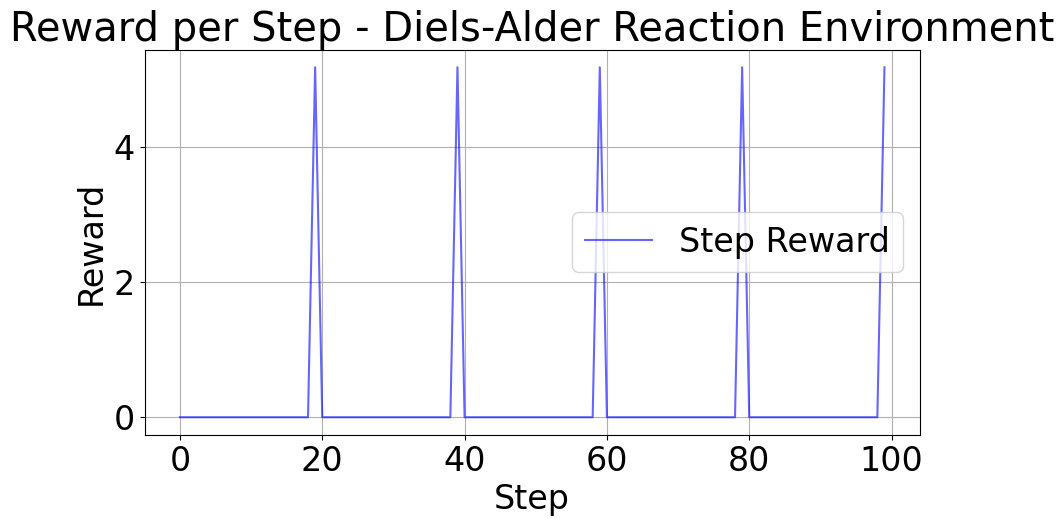

In [10]:
import matplotlib.pyplot as plt

model = PPO.load("C://Users//ASD//git//ASIDielsAlder//chemgymrl//RLMODELS//DielsAlderReact-v0//PPO//16-01-2026--12-13-20//best_model", env=env)

obs = env.reset()
total_rew = 0

# Lists to store data for plotting
rewards_history = []
steps = []

for i in range(100):
    # Predict action based on the CURRENT observation
    action, _states = model.predict(obs, deterministic=True)
    
    obs, reward, done, info = env.step(action)
    
    total_rew += reward
    
    # Store data
    rewards_history.append(reward)
    steps.append(i)
    
    if done:
        obs = env.reset()
        # Optional: break or continue depending on if you want one episode or many
        # break 

print(f"Total Reward: {total_rew}")

# --- Plotting ---
plt.figure(figsize=(10, 5))
plt.plot(steps, rewards_history, label='Step Reward', color='blue', alpha=0.6)
plt.xlabel('Step')
plt.ylabel('Reward')
plt.title('Reward per Step - Diels-Alder Reaction Environment')
plt.grid(True)
plt.legend()
plt.show()